# Notebook 3 – PCA zur Bildkomprimierung
**Maschinelles Lernen mit Python · Kapitel 12: Dimensionsreduktion**  

---

## 🎯 Lernziele dieses Notebooks

Nach Bearbeitung dieses Notebooks können Sie:
- erklären, wie PCA auf Bilddaten angewendet wird (Zerlegung in Farbkanäle)
- die **5 Schritte der PCA-Bildkomprimierung** beschreiben
- den Zusammenhang zwischen der Anzahl der Hauptkomponenten und der Bildqualität beurteilen
- den **Unterschied zu K-Means-Farbkomprimierung** (Kapitel 11) erklären

---

## 📖 Kontext

Bilder sind hochdimensionale Daten: Ein **JPEG-Bild** mit Breite B und Höhe H hat **B×H×3** Werte (3 Farbkanäle: R, G, B). PCA kann die räumliche Komplexität (Texturinformation) reduzieren, indem sie pro Farbkanal die wichtigsten Muster extrahiert.

> Unterschied: K-Means reduziert **Anzahl der Farben** (diskret) · PCA reduziert **räumliche Texturkomplexität** (kontinuierlich)

---

## 🔧 Vorbereitung: Google Drive einbinden

Das Notebook lädt ein Bild aus Ihrem Google Drive. Legen Sie eine Bilddatei (JPEG) in den angegebenen Pfad.

Mounted at /content/drive
Bild geladen: /content/drive/MyDrive/Colab Notebooks/DHBW Sommersemester 2026/Data/dein_bild.jpeg
Form:         (1024, 768, 3)  (Höhe × Breite × Farbkanäle)
Datentyp:     float64
Gesamtpixel:  786,432


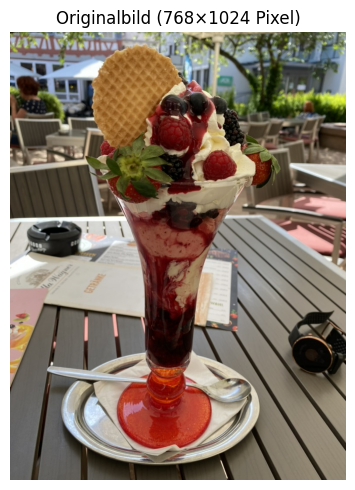

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from skimage import io
from google.colab import drive
import os

drive.mount('/content/drive')

# ⚙️ Passen Sie diesen Pfad an Ihren Google Drive an:
base_notebook_dir = "/content/drive/MyDrive/Colab Notebooks/DHBW Sommersemester 2026/Data"
file_name = "dein_bild.jpeg"  # ← Dateinamen anpassen!
path = os.path.join(base_notebook_dir, file_name)

# Bild laden und normieren (Werte zwischen 0 und 1)
img = io.imread(path) / 255.0

print(f"Bild geladen: {path}")
print(f"Form:         {img.shape}  (Höhe × Breite × Farbkanäle)")
print(f"Datentyp:     {img.dtype}")
print(f"Gesamtpixel:  {img.shape[0] * img.shape[1]:,}")

plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.title(f'Originalbild ({img.shape[1]}×{img.shape[0]} Pixel)', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Die 5 Schritte der PCA-Bildkomprimierung (erklärt)

| Schritt | Was passiert | Warum? |
|---------|-------------|--------|
| 1. Zerlegen | Bild in R, G, B-Kanäle aufteilen | PCA arbeitet auf 2D-Matrizen, nicht 3D-Tensoren |
| 2. Zentrieren | Mittelwert abziehen | PCA setzt Mittelwert = 0 voraus |
| 3. PCA | Kovarianzmatrix → Eigenvektoren berechnen | Findet Hauptrichtungen in den Pixeldaten |
| 4. Reduzieren | Top-k Komponenten behalten | Eliminiert Rauschen und Redundanz |
| 5. Rekonstruieren | Projektion zurücktransformieren | Approximiertes Bild aus k Komponenten |

PCA-Komprimierung mit 50 Hauptkomponenten:
  Rot-Kanal: 94.6% Varianz mit 50 Komponenten
  Grün-Kanal: 94.4% Varianz mit 50 Komponenten
  Blau-Kanal: 94.9% Varianz mit 50 Komponenten


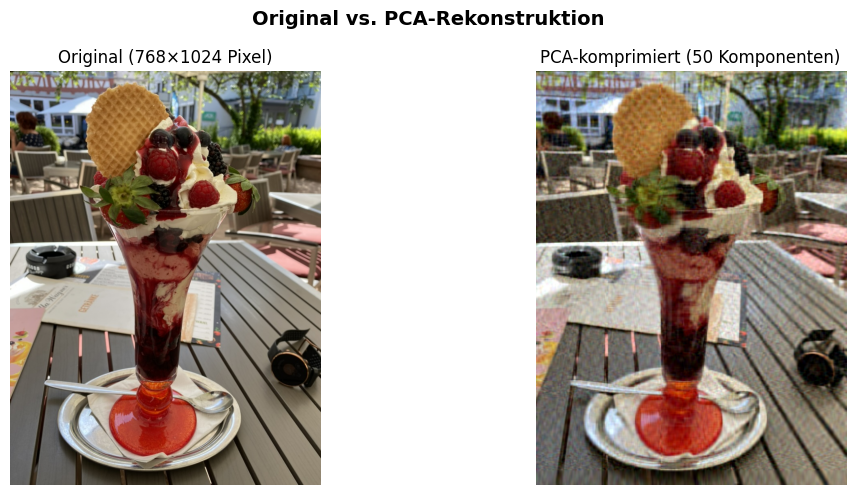

In [2]:
def pca_compress_channel(channel, n_components=50):
    """
    Komprimiert einen einzelnen Bildkanal (2D-Matrix) via PCA.

    channel:      2D-Array (Höhe × Breite), ein Farbkanal
    n_components: Anzahl der Hauptkomponenten (1 = stärkste Komprimierung)

    Rückgabe: rekonstruierter Kanal (gleiche Form wie Eingang)
    """
    pca = PCA(n_components=n_components)
    compressed = pca.fit_transform(channel)    # Schritt 3 & 4: PCA + Projektion
    reconstructed = pca.inverse_transform(compressed)  # Schritt 5: Rekonstruktion
    var_erklaert = np.sum(pca.explained_variance_ratio_)
    return reconstructed, var_erklaert


def bild_komprimieren(img, n_components=50):
    """
    Komprimiert ein RGB-Bild kanalweise via PCA.
    """
    kanal_namen = ['Rot', 'Grün', 'Blau']
    reconstructed_channels = []
    varianz_info = []

    for i in range(3):
        kanal = img[:, :, i]  # Farbkanal extrahieren
        rekonstruiert, var = pca_compress_channel(kanal, n_components)
        reconstructed_channels.append(rekonstruiert)
        varianz_info.append(var)
        print(f"  {kanal_namen[i]}-Kanal: {var*100:.1f}% Varianz mit {n_components} Komponenten")

    # Kanäle zusammenführen und auf [0,1] begrenzen
    reconstructed_img = np.stack(reconstructed_channels, axis=2)
    reconstructed_img = np.clip(reconstructed_img, 0, 1)
    return reconstructed_img, varianz_info


# Komprimierung mit 50 Hauptkomponenten
print("PCA-Komprimierung mit 50 Hauptkomponenten:")
reconstructed_50, _ = bild_komprimieren(img, n_components=50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title(f'Original ({img.shape[1]}×{img.shape[0]} Pixel)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(reconstructed_50)
axes[1].set_title(f'PCA-komprimiert (50 Komponenten)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Original vs. PCA-Rekonstruktion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Lernauftrag: Qualität vs. Komprimierung

Testen Sie verschiedene Werte für `n_components`. Ab wie vielen Hauptkomponenten ist das Bild kaum noch vom Original zu unterscheiden?

> **Hypothese formulieren:** Schreiben Sie auf, wie viele Komponenten Sie erwarten, bevor Sie den Code ausführen.


n_components = 1:
  Rot-Kanal: 22.3% Varianz mit 1 Komponenten
  Grün-Kanal: 22.5% Varianz mit 1 Komponenten
  Blau-Kanal: 28.1% Varianz mit 1 Komponenten

n_components = 5:
  Rot-Kanal: 59.9% Varianz mit 5 Komponenten
  Grün-Kanal: 56.7% Varianz mit 5 Komponenten
  Blau-Kanal: 59.8% Varianz mit 5 Komponenten

n_components = 10:
  Rot-Kanal: 74.0% Varianz mit 10 Komponenten
  Grün-Kanal: 72.8% Varianz mit 10 Komponenten
  Blau-Kanal: 74.3% Varianz mit 10 Komponenten

n_components = 20:
  Rot-Kanal: 84.8% Varianz mit 20 Komponenten
  Grün-Kanal: 84.2% Varianz mit 20 Komponenten
  Blau-Kanal: 85.4% Varianz mit 20 Komponenten

n_components = 50:
  Rot-Kanal: 94.6% Varianz mit 50 Komponenten
  Grün-Kanal: 94.4% Varianz mit 50 Komponenten
  Blau-Kanal: 94.9% Varianz mit 50 Komponenten

n_components = 100:
  Rot-Kanal: 98.3% Varianz mit 100 Komponenten
  Grün-Kanal: 98.3% Varianz mit 100 Komponenten
  Blau-Kanal: 98.4% Varianz mit 100 Komponenten


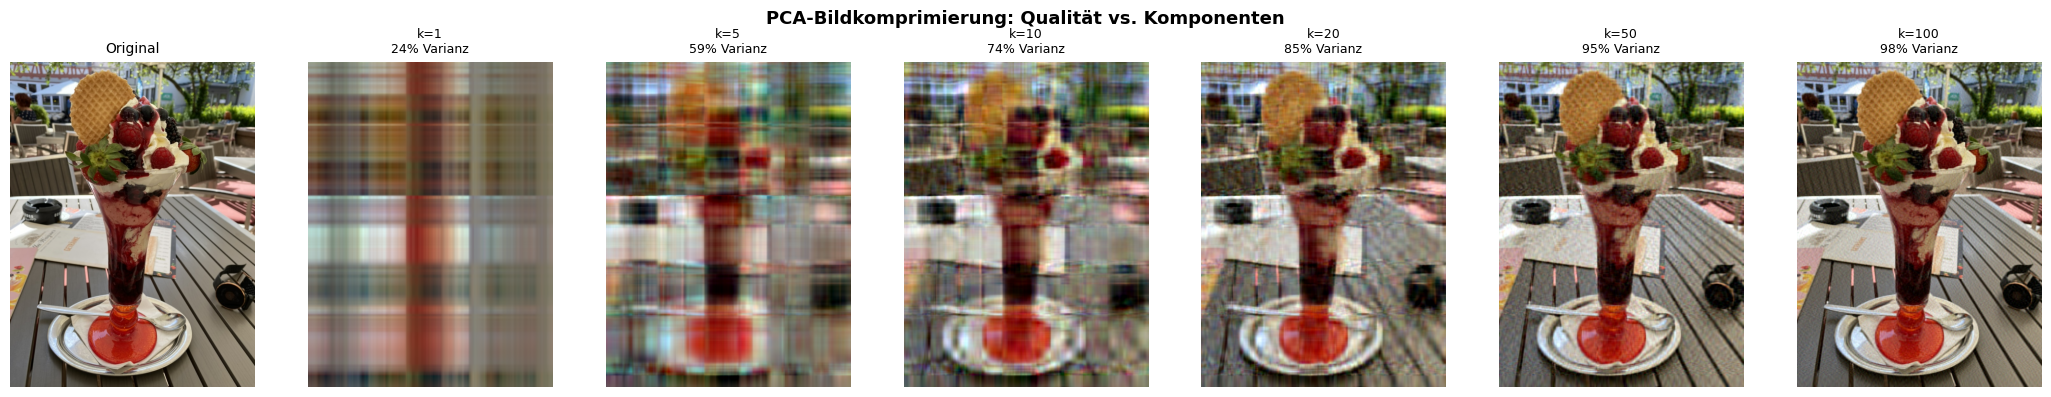


🔍 Ab wie vielen Komponenten ist der Unterschied zum Original kaum noch sichtbar?
   Notieren Sie Ihre Beobachtung hier:
   → ...


In [3]:
# Vergleich verschiedener Komprimierungsgrade
komponenten_werte = [1, 5, 10, 20, 50, 100]

n_plots = len(komponenten_werte) + 1
fig, axes = plt.subplots(1, n_plots, figsize=(3 * n_plots, 4))

# Original
axes[0].imshow(img)
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')

# Komprimierte Varianten
for idx, n in enumerate(komponenten_werte):
    print(f"\nn_components = {n}:")
    try:
        rekonstruiert, var_info = bild_komprimieren(img, n_components=n)
        mean_var = np.mean(var_info) * 100

        axes[idx + 1].imshow(rekonstruiert)
        axes[idx + 1].set_title(f'k={n}\n{mean_var:.0f}% Varianz', fontsize=9)
        axes[idx + 1].axis('off')
    except Exception as e:
        # Falls n_components > Bildbreite
        axes[idx + 1].set_title(f'k={n}\n(nicht möglich)', fontsize=9)
        axes[idx + 1].axis('off')
        print(f"  → Fehler: {e}")

plt.suptitle('PCA-Bildkomprimierung: Qualität vs. Komponenten', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("🔍 Ab wie vielen Komponenten ist der Unterschied zum Original kaum noch sichtbar?")
print("   Notieren Sie Ihre Beobachtung hier:")
print("   → ...")

---
## Vergleich: PCA vs. K-Means Bildkomprimierung

Aus Kapitel 11 kennen Sie K-Means zur Farbkomprimierung. Was ist der Unterschied?

| | **K-Means (Kap. 11)** | **PCA (Kap. 12)** |
|---|---|---|
| **Was wird reduziert?** | Anzahl der Farben | Räumliche Texturkomplexität |
| **Wie?** | Clustert ähnliche Farben | Komprimiert Pixelzeilen entlang der Hauptachsen |
| **Verlust** | Diskrete Farbpalette | Weiche Übergänge leicht verschwommen |
| **Ergebnis** | Posterisierter Look | Leicht unscharfer Look |
| **Stärke** | Sehr hohe Farbkomprimierung | Hohe strukturelle Komprimierung |

---
## 📝 Lernauftrag

**Aufgabe 1 – Beobachtung dokumentieren:**  
Notieren Sie für jede getestete Komponentenanzahl (1, 5, 10, 20, 50, 100), wie die Bildqualität subjektiv wirkt. Ab welchem Wert würden Sie sagen: "gut genug"?

**Aufgabe 2 – Varianzplot erstellen:**  
Erstellen Sie einen Plot, der die durchschnittliche erklärte Varianz (y-Achse) gegen die Anzahl der Komponenten (x-Achse) darstellt. Verwenden Sie den Rot-Kanal: `pca.fit(img[:,:,0])` und dann `np.cumsum(pca.explained_variance_ratio_)`.

**Aufgabe 3 – Graustufenbild:**  
Konvertieren Sie das Bild in Graustufen (`img_gray = np.mean(img, axis=2)`) und komprimieren Sie es mit `pca_compress_channel()`. Benötigen Sie mehr oder weniger Komponenten als beim RGB-Bild?

### Aufgabe 1 – Beobachtung (Beispielantwort)

| Komponenten (k) | Erwartete Beobachtung |
|---|---|
| k = 1 | Sehr verschwommen, nur grobe Helligkeitsverteilung erkennbar |
| k = 5 | Grobe Strukturen sichtbar, Details fehlen |
| k = 10 | Hauptstrukturen erkennbar, aber noch unscharf |
| k = 20 | Deutlich besser, meiste Strukturen erhalten |
| k = 50 | Kaum noch Unterschied zum Original sichtbar |
| k = 100 | Praktisch identisch mit dem Original |

**Empfehlung:** Ab ca. k = 30–50 ist für die meisten natürlichen Bilder kein relevanter Qualitätsverlust mehr sichtbar. Der genaue Wert hängt vom Bild ab.

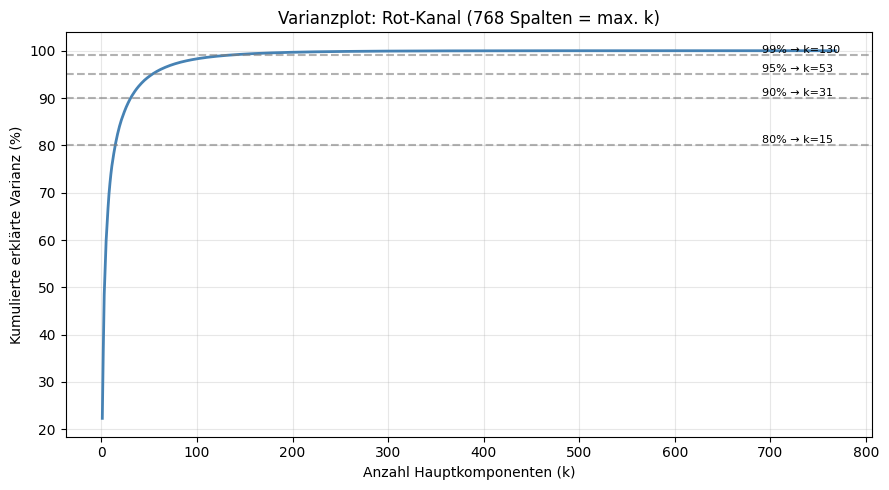

In [6]:
# Aufgabe 2: Varianzplot
# Varianzplot für den Rot-Kanal
kanal_rot = img[:, :, 0]
pca_rot = PCA()
pca_rot.fit(kanal_rot)

cumvar = np.cumsum(pca_rot.explained_variance_ratio_)
n_comps = range(1, len(cumvar) + 1)

plt.figure(figsize=(9, 5))
plt.plot(n_comps, cumvar * 100, 'steelblue', linewidth=2)
for schwelle in [80, 90, 95, 99]:
    n_bei_schwelle = np.argmax(cumvar >= schwelle/100) + 1
    plt.axhline(y=schwelle, color='gray', linestyle='--', alpha=0.6)
    plt.text(len(n_comps)*0.9, schwelle+0.5, f'{schwelle}% → k={n_bei_schwelle}', fontsize=8)

plt.xlabel('Anzahl Hauptkomponenten (k)')
plt.ylabel('Kumulierte erklärte Varianz (%)')
plt.title(f'Varianzplot: Rot-Kanal ({kanal_rot.shape[1]} Spalten = max. k)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Form Graustufenbild: (1024, 768)
Mit 50 Komponenten: 94.4% Varianz erklärt


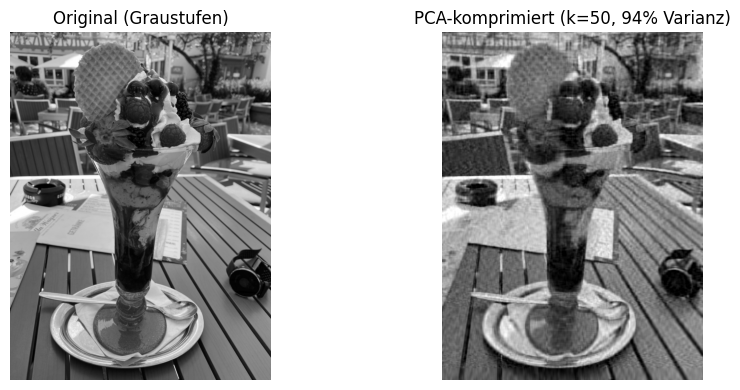

In [7]:
# Aufgabe 3: Graustufenbild komprimieren

img_gray = np.mean(img, axis=2)  # RGB → Graustufen
print(f"Form Graustufenbild: {img_gray.shape}")

# Komprimierung
img_gray_rekonstruiert, var_gray = pca_compress_channel(img_gray, n_components=50)
img_gray_rekonstruiert = np.clip(img_gray_rekonstruiert, 0, 1)

print(f"Mit 50 Komponenten: {var_gray*100:.1f}% Varianz erklärt")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original (Graustufen)')
axes[0].axis('off')
axes[1].imshow(img_gray_rekonstruiert, cmap='gray')
axes[1].set_title(f'PCA-komprimiert (k=50, {var_gray*100:.0f}% Varianz)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

**Erwartetes Ergebnis:
** Das Graustufenbild benötigt **weniger Komponenten** als das RGB-Bild, um eine ähnliche Qualität zu erreichen, da nur ein Kanal verarbeitet wird. Die Varianzstruktur pro Kanal ist dieselbe – aber bei Graustufen gibt es keine kanalspezifischen Unterschiede mehr.
